In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#!pip install -U pandasql

In [3]:
import pandas as pd
from pandasql import sqldf
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
pysqldf = lambda q: sqldf(q, globals())

# Titanic: Case Study in Probability

In this case study, we look at the passenger data from the *Titanic* and demonstrate some concepts in probability.
In the process, we will need to introduce a few concepts in ETL (Extract, Transform, and Load) and EDA (Exploratory Data Analysis) that we won't cover for a few chapters.
You may think of it as a preview.
And when we get to the relevant chapters, you can come back to this case study and find another example of *those* concepts.
We will also return to this case study later in the semester and add some Monte Carlo Simulation.

The *Titanic* data is interesting for a few reasons.
First, it's a well known event with widely available domain knowledge.
Second, it often shows up as a data science example.
However, it's not really the straightforward example it's often made out to be and we need to spend a moment discussing why.

## Independently and Identically Distributed

Almost all of our algorithms, all of our analytics go back to probability and the famous "balls in an urn" example.
When you get purchase data, disease data, forest data, water level data, and start to analyze it, most tools depend on a somewhat cryptic assumption: "the data is i.i.d.".
What's this "i.i.d."?

<img alt="IID" src="resources/iid.jpg" width="50%"/>

IID stands for "identically and independently distributed".
If we think of the canonical example of balls in an urn, this means that the probability of picking any particular ball must be the same for *every* ball and not depend on picking *any* particular ball.
Thus the probability of picking the first red ball cannot be different than the probability of picking the second red ball (identically).
For the urn example, this comes from the assumption "with replacement" that is often, even usually, added.
Additionaly, the probability of picking a red ball after picking a green ball cannot be different from picking a red ball first (independent).
It does *not* say that the probability of picking a red ball must be the same as the probability of picking a green ball.
This is just a claim about the constancy of the underlying process that's generating observations.

The "independently" assumption means successive observations are unrelated.
In other words, picking a red ball cannot change the probability of picking a green ball.
A real life example might help.

Let's say we have a year's worth of purchase data that we're analyzing for a daily deals company (or maybe we're analyzing hard disk defects or disease outbreaks).
In order to receive a daily deals email, you have to register so we can send you the email.
Only a small fraction of those who register actually make a purchase.
We want to understand the behavior of those purchasers so that we might be able to influence non-purchasers to become purchasers.

Here the "urn" is the process that covers the selection of deals, how they're advertised, potential customers, their incomes and budgets, preferences, marketing, and what they had to eat that morning.
Each "ball" is a purchase or not (you can think of this as drawing "red"--purchase--or "green"--no purchase-balls from the urn).

So are these data IID?
In the strictess sense, probably not, they're very unlikely to be *identically* distributed.
The issue is that the process is most definitely changing...competitors are changing their advertising, new items come up for sale, etc.
However, we will often treat the data as identically distributed because the things that are changing are not, in general, known.
This is a general issue in Data Science that needs to be kept in mind.
The relationships we study in sales and marketing are not remotely as constant as the relationships studied in physics and chemistry.

Now, are these data independent?
That is, is every purchase independent of every other purchase?

Well, not *all* of them.
Someone may be a purchaser because a friend purchased something.
Someone may make a purchase because they made a purchase earlier in the month (or year) and like the quality of the product or the customer service.
If a customer makes more than one purchase, then their characteristics ("features") are represented two (2) or more times in the data.
Because one ball in the urn ("purchase") affected another ball in the urn ("purchase"), the balls (observations) are not independently distributed.
We generally handle this problem by thinking very hard about it and then concluding it doesn't matter.
(As I say, almost all of our analytical tools require IID...if we conclude it does matter, everything gets trickier).
However, even if we conclude that the lack of IID doesn't matter for the analysis *as a whole*, it may matter incredibly if we start building *training* and *test* data sets because elements in the two sets may be correlated with each other.
We'll return to *that* problem later in the course.
For now, let us return to Titanic.

## Titanic as an Urn of Balls

The "urn" in this case is the process whereby people found themselves as passengers on Titanic, the ensuing journey, collision with the iceberg, the evacuation procedures, and subsequent rescue of those in the lifeboats.
Each "ball"--the "red" and "green" in this case--is surviving or not surviving the disaster.
Of course, people who never boarded Titanic survived.
But, if you were the wife or child of someone who boarded Titanic, you had a high probability of being there yourself.
And, as it turns out, survival was also highly correlated among families.
Having a family member of some kind on board is actually a feature in the data set but that doesn't quite settle the question of whether the outcomes (draws from the urn) are independent.
They don't seem to be.

We have to think about whether this matters to our results or not.
And it's important to realize that, in the end, our analyses are always approximations and estimates.

## Titanic as a Single Event

One final word before we turn to the analysis.
One might reasonably object to the analysis of the Titanic data as a *probabilitistic* or even just *predictive* exercise because it was a one time event.
Obviously, it makes sense to build a model to predict whether a picture is a dog or a cat, or to build a model from past purchases to predict future purchases, because both of these are on-going or repeating *processes*.

But can we build a model of Titanic survivability in a meaningful way?
My response is that it is worthwhile to look at the Titanic data for a number of reasons.
First, despite its not being a repeating process, analyzing the data still has pedagogical value.
Second, it's interesting and available (which is no mean feat).
Third, we can engage in some "hypothetical history".
Deterministic processes with many small inputs need only a nudge here and there to go in a completely different direction.
Thus, we can engage in a bit of hypothetical history, explore the multiverse if you like, by treating a one time event probabilistically.
Finally, *Titanic* had two sister ships.
One of them actually sank in the Mediterrean during World War I and *sank even faster* than Titanic did.
However, there was significantly less loss of life.
Why?
The Mediterrean is much warmer than the North Atlantic and *Olympic* was nearer an island from which rescue boats were launched.
The third sister ship sailed without incident.


```{important}
Many of the topics discussed here will not have been covered yet.
For example, [ETL](../data/index.ipynb) and EDA (../eda/index.ipynb) are not full explained until later chapters.
Just skim those sections and anything that says "Review" should be interpreted as "Preview" for now.
When you reach ETL and EDA, come back to these examples.

Markdown cells in Jupyter notebooks support raw HTML and CSS as well as Markdown. This isn't true of all notebook platforms, however. For example, Colab does not support raw HTML.
```

## Domain Knowledge

Domain knowledge is incredibly important for data science and should generally, after the identification of the problem/question, be the main starting point.
Although we will concern ourselves chiefly with probability, there exists several interesting questions in hypothetical history surrounding Titanic.
One of these is, "how many more could have been saved if there had been more lifeboats aboard Titanic?".
Although we will not address this question directly (yet), domain knowledge will even help us with our investigation of probabilities so let's see what we can find out.

1. According to [Wikipedia](https://en.wikipedia.org/wiki/RMS_Titanic)'s main and secondary articles on Titanic, there were an estimated 2,227 passengers and crew on board when Titanic sank (1317 passengers). However, Titanic was not full. The official capacity of Titanic was more than 3,547 passengers and crew.
2. The capacity, by class, of Titanic was as follows:

| Type      | Count |
|-----------|------:|
| 1st Class | 833   |
| 2nd Class | 614   |
| 3rd Class | 1,006  |
| Crew      | 900   |


3. The location of cabins differed and played a role in passenger survival. The less desirable (3rd Class) cabins were lower (Decks D-G, but mostly F & G) and the more desirable (1st class) cabins were higher (Decks A-C, although 1st class facilities extended down to F Deck). 2nd Class Cabins were located on D-F Decks. G Desk flooded within 5-10 minutes after the collision and F Deck shortly thereafter.

### Lifeboats

Lifeboats figured heavily into the disaster and subsequent investigation. Several forces conspired to doom any vessel of Titanic's size should there be a disaster at sea. First, maritime regulations had not caught up with ships on the scale of Titanic. Second, there was a general, anecdotally supported view, of "every ship its own lifeboat" and therefore if a ship was "unsinkable", if disaster did strike, it would remain afloat until rescue ships came and the few available lifeboats would ferry the passengers and crew to safety.

1. Titanic was designed to carry 64 lifeboats. That number was halved to 32 then again to 16, so as to maximize the available deckspace.
2. In the end, Titanic carried 14 regular lifeboats (65 passengers officially, 40 in practice), 2 cutters (40 passengers officially), and 4 collapsible lifeboats--more like rafts (47 passengers officially).

The total capacity of the lifeboats was 828. If Titanic had had 64 regular lifeboats, the capacity would have been 2,560, which was more than enough for the passengers and crew at the time, although not enough if Titanic had been at capacity. However, that doesn't mean that Titanic could have successfully *launched* those lifeboats.

Aside from the number of lifeboats, there were several ways in which the lifeboats were problematic and central to the disaster.

1. The lifeboats and infrastructure were new, during the disaster, several lifeboats were lowered only with difficulty.
2. There was only precursory training on the lifeboat system before sailing and there were no lifeboat drills once Titanic left Southampton. Many of the crew had no idea what they were supposed to do or where they were supposed to be in the event of a disaster (the instructions had been left unread or forgotten).
3. Crew were reticent to load many people onto lifeboats because they were afraid they would buckle. In fact, the lifeboats had been tested with the weight of 70 men; a fact they were unaware of.
4. Passengers were not sufficiently informed or aware of their situation and many refused to get into lifeboats until too late.
5. The launch of the lifeboats did not start until nearly a hour after Titanic struck the iceberg. By this time, the 3rd class passenger decks had been fully flooded.
6. Most fatefully, the starboard crew and the port crew interpreted the instruction "women and children in and lower away" differently. Murdoch and crew, on the starboard side, interpreted the instruction to mean: women and children *first* while Lightoller and crew, working on the port side, intrepreted the instruction to mean: women and children *only*.

Thus, on the starboard side, if there were no women or children waiting, men were permitted into the lifeboats whereas on the port side, lifeboats were lowered nearly empty even if men were waiting for a spot.
Interestingly, James Cameron weaves some of this information into in his movie [*Titanic*](https://www.youtube.com/watch?v=iPskEv01h98), although not necessarily in a historically accurate way.


| Lifeboat tally |        |           |        |
|----------------|--------|-----------|--------|
| Port           |        | Starboard |        |
| Boat           | Aboard | Boat      | Aboard |
| 2              | 18     | 1         | 12     |
| 4              | 42     | 3         | 40     |
| 6              | 29     | 5         | 36     |
| 8              | 28     | 7         | 28     |
| 10             | 39     | 9         | 38     |
| 12             | 29     | 11        | 68     |
| 14             | 48     | 13        | 63     |
| 16             | 39     | 15        | 64     |
| B              | (21)   | A         | 12     |
| D              | 22     | C         | 45     |
| Total:         | 308    | Total:    | 404    |


The numbers refer to regular lifeboats/cutters and the letters to the collapsible lifeboats. Lifeboat A floated off the deck while being launched and Lifeboat B landed upside down; surviving passengers were transfered to other lifeboats.

Titanic struck the iceberg at 11:40 pm, ship's time.
The lower decks were flooded in 10 minutes and the lifeboats were not launched for a full hour after the iceberg was struck.

## <a id="etl">ETL</a>


```{admonition} Review

1. What does ETL stand for?
2. In terms a "Muggle" would understand, what is "tidy data"?
3. Is the Titanic data set presented here tidy or messy data? Given an example of the opposite.
4. How do the concepts of provenance and reproducibility apply to this example?
```

There are several copies of "the" Titanic data set available.
The most extensive one is from Lake Forest University, `titantic3`.
As described by M. L. Frank, `titanic` is drawn from *Encyclopedia Titanica* and contains information for all passengers but not crew.
About half of the passengers are missing values for `age`.

`titanic2` was created by Robert Dawson of St. Mary's University to include records for the crew.
Additionally, all records have a value for `age` but it has been turned into a categorical variable with values `adult` or `child`.

`titanic3` was created by Thomas Cason of the University of Virginia and is the most up-to-date data set for the Titanic as of 2 August 1999.
It does not include crew records.

### Data Dictionary

The `titanic3` data set has the following variables:


| Variable  | Description                       | Notes                                                                                                                    |
|-----------|-----------------------------------|---------------------------------------------------------------------------------------------------------------------------|
| pclass    | Passenger Class                   | (1 = 1st, 2 = 2nd, 3 = 3rd)                                                                                                 |
| survived  | Survived or not                       | (0 = No, 1 = Yes)                                                                                                         |
| name      | Name                              |                                                                                                                           |
| sex   | Sex                               |                                                                                                                           |
| age   |   Age                                 |                                                                                                                           |
| sibsp     | Number of Siblings/Spouses Aboard | Brother, Sister, Stepbrother, or Stepsister, Husband or Wife of Passenger Aboard Titanic (Mistresses and Fiances Ignored) |
| parch     | Number of Parents/Children Aboard | Mother or Father, Son, Daughter, Stepson, or Stepdaughter of Passenger Aboard Titanic                                     |
| ticket    | Ticket Number                     |                                                                                                                           |
| fare      | Passenger Fare (British pound)    |                                                                                                                           |
| cabin     | Cabin                             |                                                                                                                           |
| embarked  | Port of Embarkation               | (C = Cherbourg, Q = Queenstown, S = Southampton)                                                                          |
| boat      | Lifeboat                          |                                                                                                                           |
| body      | Body Identification Number        |                                                                                                                           |
| home.dest | Home/Destination                  |                                                                                                                           |


This data set represents "tidy" data according to the Hadley Wickham's definition:

1. Each row is an observation (a passenger).
2. Each column is a variable (age, name).
3. Each "cell" (intersection of row and column) is a value of that variable for that observation.

ETL stands for *extract, transform, and load*.
Remember when we mentioned overloaded terms in connection to normalization?
Transform is another overloaded term.
In this case, "transform" is associated with turning *messy* data into *tidy data*.
As a result, there are no obvious transforms we need to apply at this time because the data comes from a single file that is already meets the definition of tidy data (which we will go over in a later chapter).
We will also see other definitions of "transform" in later chapters.

<img alt="Not Those Transforms" src="resources/transforms.jpg" width="50%"/>

### Obtaining the Data

The data can be found at:

http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/titanic3.xls

which we can load directly into a Pandas `DataFrame`.

In [5]:
titanic = pd.read_csv("https://raw.githubusercontent.com/fundamentals-of-data-science/datasets/master/titanic.csv")

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
        <tt>df.info()</tt> can be used to get basic information about a DataFrame including variable names, total entries with values ("non-null"), and the storage data type.
        Using <tt>info()</tt> can be your first test that everything happened as you expected.
For example, the Data Dictionary could be wrong, or one or more variables in might have a different value in the file than they do in the Data Dictionary. 
    </p>
    <p>During ETL, once you have your data in a DataFrame, this should be the first step.</p>
</div>

In [6]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(7), object(7)
memory usage: 143.4+ KB


Here we can see that the variables are as defined in the data dictionary.
Additionally, each of the variables are the expected type.
For example, `name`, `sex`, `cabin`, `embarked`, `boat`, `home.dest` are all strings ("object").
The only variable that's questionnable is `ticket` (Ticket Number) but it's entirely possible for ticket numbers to include alphabetic characters and not just numbers.

Given that some of the categorical variables have numeric encodings, all of the other variables have the proper numeric *programming language* types (`pclass`, `survived`, `age`, `sibsp`, `parch`, `fare`, `body`)

Looking through the non-null counts, we can see that the maximum number of observations we should have is 1309 for any given variable.
Based on this, we can see we have only partial information for `age`, `fare`, `cabin`, `embarked`, `boat`, `body`, and `home.dest`.
The missing values make sense in some cases.
If the passenger did not survive, they may not necessarily have a `boat` (lifeboat) number.
If the passenger did survive or did not survive and wasn't recovered, they won't have a body identification number.

And just in general, it makes sense that records might not have survived for every passenger so that we might know their `cabin` or `home.dest`.
And even so, these might be correlated with other variables (such as lacking a cabin number and 3rd class) and we might check them later.

Finally, we must be cautious that just because `pclass` is encoded as an `int`, this is just a code, 1st class plus 2nd class does not equal 3rd class!
Taking the average of this variable is meaningless.

<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>
        Name the main <strong>data science</strong> data types. What's the difference between computer/programming language data types and data science data types?</p>
</div>

## <a id="eda">Exploratory Data Analysis</a>

<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review (Module 5)</strong>
    <p>What process do we follow in order to make Exploratory Data Analysis (EDA) as rigorous as possible?</p>
</div>

We start with an overall count of the records so we can use it later:


In [7]:
passengers = len(titanic)

In [8]:
passengers

1310

## Variables Examined

There are a number of variables that we will not be using.
For example, `name` will not be used.
Although it's entirely possible someone might have said, "Do you know how I am?", we have no way of knowing this and operationalizing that information based on the name alone.

Additionally, we will not use:

* `ticket` (ticket number) - it's not feasible to see how ticket number influenced survival.
* `embarked` (port of embarcation) - it's unlikely that the port that someone boarded *Titanic* is relevant.
* `home.dest` (home destination) - it's not likely that the home destination of a passenger influenced their survival.

Finally, we won't use:

* `lifeboat` - because being in a lifeboat basically indicates that someone survived.
* `body` - because a body number basically indicates that someone did *not* survive.

Therefore, we will look at:

1. `pclass`
2. `sex`
3. `age`
4. `sibsp` (siblings)
5. `parch` (parents or children)
6. `fare`
7. `cabin` (possibly more information that just pclass)
8. `survival`


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>Our basic framework for EDA in this course is:</p>
    <ol>
        <li>Single Variable Exploration</li>
        <li>Pairwise Comparisons guided by
            <ol>
                <li>domain knowledge</li>
                <li>question or problem</li>
                <li>correlation</li>
            </ol>
        </li>
        <li>Higher Dimension Comparisons</li>
    </ol>
    <p>and we will follow that here. You should not deviate from the framework on your Labs and Problem Sets.</p>    
</div>


### Passenger Class (pclass)

`pclass` is the class of the passenger, either 1st, 2nd, or 3rd class.
It is a categorical variable but it has been encoded here as an integer.
We need to be careful.
`pclass` can be seen as a proxy variable for socio-economic status and indicative of the location of the person's cabin, which proved to be vital during the disaster.
At 11:40p, most of the 3rd class passengers would have been in their cabins where as the 1st class passengers would have been closer to the deck.

We will first look at the `pclass` variable and then look at simple counts or distributions by value.
What do we expect to see?

We have a count of passenger *cabins* above.
There were roughly 800 1st class, 600 2nd class, and 1000 3rd class cabins.
Now, the 3rd class cabins could hold more people than the 1st class cabins so there should be many more 3rd class passengers than 1st class.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>There are at least two ways to calculate counts by value. We'll show the way it was done in <em>Fundamentals</em> and then show how we can use <tt>pandasql</tt> as well.</p>
    <p><tt>describe()</tt> returns a Series which does not have "nice" formatting. Wrapping a Series in a DataFrame gives us the "nice" HTML formatting.</p>
</div>

As we have twice noted, if we `describe()` `pclass`, Pandas will fulfill our command:

In [9]:
pd.DataFrame(titanic["pclass"].describe())

,pclass
count,1309.000000
mean,2.294882
std,0.837836
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,3.000000


but it doesn't make any sense.
It is meaningless to say that the mean class was "2.29".
Pandas isn't going to automatically do the right thing.
You should by not "describing" a categorical variable, even with a numeric encoding.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>You can access a variable in a DataFrame using either Dictionary notation: <tt>titanic["pclass"]</tt> or Object notation: <tt>titanic.pclass</tt></p>
    <p>Which one you use is entirely up to you but it's best to be consistent. If you have variables with spaces in the names, you'll have to use the "dictionary" notation and you should just stick with it. You'll be forced to use dictionary notation if you access multiple variables at once <tt>titanic[["pclass", "sex"]]</tt>.</p>
    <p>Because you almost always have to use Dictionary notation at some point, I usually just stick with Dictionary notation.</p>
</div>


<div style="background: tomato; margin:20px; padding: 20px;">
    <strong>Warning</strong>
    <p>I sometimes see students assign variables in DataFrames to another variable:
    <pre style="background: tomato;">
    pclass = titanic["pclass"]
    </pre>
    I'm not exactly sure why one would do that so <strong>don't</strong>. There's just no reason to do this whatsoever, especially when you can use Object notation.</p>
</div>



Thus even though `pclass` is numeric, we should treat it as categorical data and just look at counts and relative frequency.
Relative frequency holds a particular interested for us because it can be thought of as an estimate of probability.

In [10]:
pd.DataFrame(titanic["pclass"].value_counts().sort_index())

,pclass
1.0,323
2.0,277
3.0,709


Our hypothesis is nearly correct.
There are about the same number of 1st and 2nd class passengers (at least proportionate to their count of cabins) but there are more than twice as many 3rd class passengers.

In [11]:
pd.DataFrame(titanic["pclass"].value_counts(normalize=True).sort_index())

,pclass
1.0,0.246753
2.0,0.211612
3.0,0.541635


More than half the passengers were 3rd class, with 1st and 2nd classes making up 25% and 20% respectively.

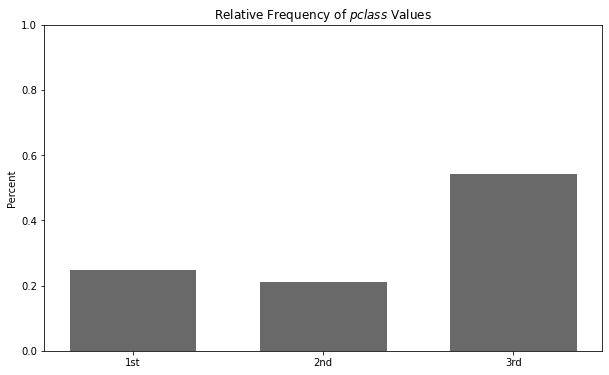

In [12]:
pclass_proportions = titanic["pclass"].value_counts(normalize=True).sort_index()
x = range( len( pclass_proportions))
width = 1/1.5

figure = plt.figure(figsize=(10, 6))

axes = figure.add_subplot(1, 1, 1)
axes.bar(x, pclass_proportions, width, color="dimgray", align="center")
axes.set_xticks([0, 1, 2])
axes.set_xticklabels(["1st", "2nd", "3rd"])
axes.set_title( "Relative Frequency of $pclass$ Values")
axes.set_ylabel( "Percent")
axes.set_ylim((0,1))
axes.xaxis.grid(False)

plt.show()
plt.close()

<div style="background: lemonchiffon; margin: 20px; padding: 20px">
    <strong>Note</strong>
    <p>
        Remember, although in <em>Fundamentals</em> (Module 5) we show both the bar chart for counts and bar chart for relative frequency (proportions), we don't <em>usually</em> need show both in the real world. When they are right next to each other, they have the exact same shapes, just different y-axis labels.
    </p>
    <p>
        When charting percentages it's often desirable to make the y-range the full 0 to 100%, if the bars all add up to 100%.
    </p>
</div>

Here is the same calculation using `pandasql`.
Either way is completely fine, although `pandasql` is probably more useful for more complex calculations including joins across data frames.

In [13]:
pclass_counts = pysqldf("SELECT pclass, count(*) AS cnt FROM titanic GROUP BY pclass ORDER BY pclass")

In [14]:
pclass_counts

,pclass,cnt
0,NaN,1
1,1.0,323
2,2.0,277
3,3.0,709


We can add the percent by manipulating the dataframe:

In [15]:
pclass_counts["percent"] = pclass_counts["cnt"]/passengers

In [16]:
pclass_counts

,pclass,cnt,percent
0,NaN,1,0.000763
1,1.0,323,0.246565
2,2.0,277,0.211450
3,3.0,709,0.541221


Because we usually *do* want both you'd think that the `pandas` library would let us but, no, it does not.
In fact, there's a long discussion about this very [feature](https://github.com/pandas-dev/pandas/issues/16851) where they convinced themselves it belonged in a "cookbook".
We will follow the path blazed by the OP and write our own.
This will also demonstrate a bit of OOP hacking in Python.

First, we create a function.
This function takes `self` as the first argument, which will be a pandas `Series` object.

In [17]:
from pandas.core.algorithms import value_counts
from pandas.core.reshape.concat import concat


In [18]:
def summarize_category(series):
        res_regu = value_counts(series)
        res_norm = value_counts(series, normalize=True)
        result = concat([res_regu, res_norm], axis=1, keys=['Count', 'Frequency'])
        result = result.sort_index()
        return result

All `Series` objects within this notebook, from this point on, will have the `summarize_category()` *method*.

In [19]:
summarize_category(titanic["pclass"])

,Count,Frequency
1.0,323,0.246753
2.0,277,0.211612
3.0,709,0.541635


### Relative Frequency to Probability

We've previously mentioned that probability is the calculus of uncertainy.
How does uncertainty come into play here?
At first glance, it would seem like there is *no* uncertainty here at all because the *Titanic* is not an on-going process.
For an *on-going* process, we can use frequencies to quantitfy our uncertainty about what the next observation is going to be.
If we have 1309 observations, what do we expect the 1310th one to be?
This interpretation--which is the usual one for Data Science--doesn't make sense in the case of the Titanic, it's not always sinking, spitting out new observations. :/

Instead, for problems like Titanic, we think of the uncertainty as covering a randomly selected observation.
If we just pick a passenger off *Titanic* at random, what kind of passenger might it be?
There is a good chance (54%), that it will be a 3rd class passenger.
Using our probability notation, we have:

$p(pclass:3rd) = 54.2\%$

Similarly,

$p(pclass:1st) = 24.7\%$

and

$p(pclass:2nd) = 21.2\%$


<div style="background: lemonchiffon; margin: 20px; padding: 20px;">
    <strong>Note</strong>
<p>It is not the usual practice to restate all the relative frequencies in terms of probabilities.
We are doing it in this case study to ground the discussion of probabilities in a real problem with real data.
We usually treat such relative frequencies as *implicit* estimates of probability.
    With the understanding that uncertainty underlies all such real world processes.</p>
    
</div>

## Sex (`sex`)

Sex is a categorical variable.
Althogh we know that the variable is categorical, we don't know the encoding.
The data dictionary doesn't give us any information on what the values of this variable look like so let's see what the possibilities are:

In [20]:
titanic["sex"].unique()

array(['female', 'male', nan], dtype=object)

The values are the string literals "female" and "male".
If we were to be using these values in a model, we might need to convert them them but we shouldn't do so prematurely.
Leave such transformations until they're actually needed.

The distribution of the sexes is generally 50/50 but it's unlikely that we would have had such a distribution on Titanic.
Given the times (1912), it's much more likely that there were more men than woman passengers, especially for 3rd class.

In [21]:
summarize_category(titanic["sex"])

,Count,Frequency
female,466,0.355997
male,843,0.644003


As we hypothesized, there were nearly twice as many men as women passengers.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
        You probably don't <em>need</em> to plot a variable with only two possible values.
    </p>
</div>

Following our previous discussion about probabilities, we can interpret these frequencies as the following probabilities:

$p(sex:female) = 35.6\%$

and

$p(sex:male) = 64.4\%$

### Age (`age`)

Age is a numeric variable.
When we examined the data after import, some variables had missing values.
This included `age` which only had 1046 observations out of 1309 with a value for `age`.
We expect the range of age to be between 0 and 100 (although the maximum lifespan of humans is generally estimated to be around 120, it is a rare occurence).
As for the distribution of age, it's difficult to surmise.
What we would like as a baseline is the age distribution of 1912 Europe and the US (one wasn't available).
Even with such a baseline, one would hypothesize that Titanic's demographics would generally skew older than the general population in 1912 because of the prevalence of businessmen and immigrants seeking their fortunes in the New World at the time (and it *was* business*men* in 1912 for the most part).

Because there are missing values, what base should we use when calculating frequencies?
It depends on if we want:

$p(age)$

or

$p(age|known)$

In the first case, we make "unknown" a possible outcome.
In the second case, condition the probability on knowing the age, so that we have, "what's the probability of a passenger being 2 years old given we know how old they are".

We can go with the first.

Because `age` is numeric, it helps to get a sense of the values.


In [22]:
pd.DataFrame(titanic["age"].describe())

,age
count,1046.000000
mean,29.881135
std,14.413500
min,0.166700
25%,21.000000
50%,28.000000
75%,39.000000
max,80.000000


The minimum age is 0.17 years (two months).
The maximum age is 80.
We don't know if that's the oldest passenger; that's only the oldest passenger for which we have data.
The mean age is nearly 30 and the median is 28.
Is that young?
A quick search did not reveal any average age information for either the United State or the UK during 1912.
We do know that the median age of those populations has been increasing over time so it might have been as low as 28 in 1912.


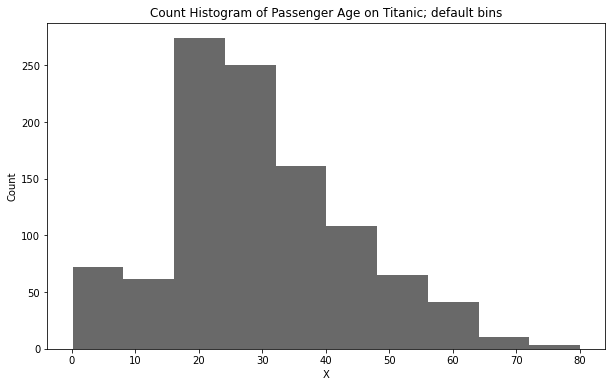

In [23]:
figure = plt.figure(figsize=(10, 6))

axes = figure.add_subplot(1, 1, 1)
axes.hist( titanic[ "age"], color="DimGray")
axes.set_ylabel( "Count")
axes.set_xlabel( "X")
axes.set_title("Count Histogram of Passenger Age on Titanic; default bins")


plt.show()
plt.close()

There is a definite and unexpected cutoff at around 18 years of age.
One explanation is that for those with no age, they were most likely to be children.
Another explanation is that there were more single immigrants among the 3rd class passengers than families amongst the 1st class passengers.
Because there were more 3rd class passengers, there were more single and therefore adult passengers.
There was also the whole "children should be seen and not heard" vibe of the era.

* We should look to see if the missing ages correlate with any other variable.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
It's easy to get side tracked when doing EDA.
Generally, as you start doing single variable EDA, and questions arise, make a note of them and return to the important ones after you have finished looking at each variable.</p>
</div>

Continuous probability distributions are difficult to work with.
If this is our *goal*, we can discretize (put values into buckets) our data.
In this case, it makes sense to transform `age` into "buckets" of ten years called `decades`.
In other cases, you might convert age into "school", "working", and "retired" or "young", "adult", "senior" or even "Gen Z", "Millennial", "Gen X", "Boomer", "Silent".

In [24]:
titanic["decade"] = (titanic["age"] // 10) * 10

In [25]:
summarize_category(titanic["decade"])

,Count,Frequency
0.0,82,0.078394
10.0,143,0.136711
20.0,344,0.328872
30.0,232,0.221797
40.0,135,0.129063
50.0,70,0.066922
60.0,32,0.030593
70.0,7,0.006692
80.0,1,0.000956


As a result, we can calculate the probability of a random passenger being in their 50's as:

$p(decade: 50) = 6.7\%$

What's $p(decade: 30)$?

### Siblings or Spouses (`sibsp`)

The variable is numeric (integer).
The data dictionary says that this value represents the number of siblings or spouses aboard Titanic, which included Brother, Sister, Stepbrother, or Stepsister, Husband or Wife of Passenger Aboard Titanic (Mistresses and Fiances Ignored).
At least they had the decency to ignore mistresses, I guess.
There are no missing values according to our examination of the data when it was imported.

It's difficult to hypothesize in this case, what the distribution will be because spouses and siblings are combined and these are very different things.
In general, it's better to work with data that has not been transformed--in the EDA or feature sense--and make your own transformations.
Unfortunately, you will often find that others have already done some transformation or aggregation and you'll have to work with it.

Based on our look at `age`, we surmise there are a lot of young, single passengers so we expect 0 to be the most common value for `sibsp`.
Unfortunately, we don't know if 1 means, a husband/wife or brother/sister.

Let's look at the distribution of values:

In [26]:
pd.DataFrame(titanic["sibsp"].describe())

,sibsp
count,1309.000000
mean,0.498854
std,1.041658
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,8.000000


As we hypothesized, there are a lot of single, no-sibling passengers on Titanic.
The minimum value of `sibsp` is 0 (no spouse or sibling) and the maximum is 8 (does that mean 8 siblings or 7 siblings and a spouse?).

For count variables with small ranges like `sibsp`, it is often easier to treat the variable as an ordered, categorical variable than as a numeric variable.

In [27]:
sibsp_counts = summarize_category(titanic["sibsp"])

In [28]:
sibsp_counts

,Count,Frequency
0.0,891,0.680672
1.0,319,0.243697
2.0,42,0.032086
3.0,20,0.015279
4.0,22,0.016807
5.0,6,0.004584
8.0,9,0.006875


A full 68% of the passengers on Titanic were single, with no sibling aboard.
This may correlate with and explain our findings with `age` but we'll need to look at the next variable (`parch`) as well.

We can give this a probabilistic interpretation as well:

$p(sibling-or-spouse: no) = 68.1\%$

Let's get a sense for the true magnitude of the frequencies:

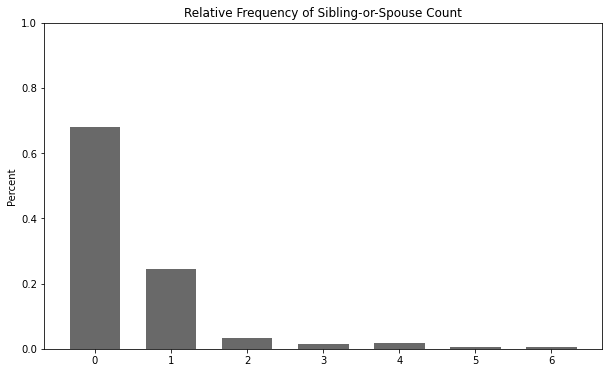

In [29]:
x = range(sibsp_counts.shape[0])
width = 1/1.5

figure = plt.figure(figsize=(10, 6))

axes = figure.add_subplot(1, 1, 1)
axes.bar(x, sibsp_counts["Frequency"], width, color="dimgray", align="center")
axes.set_xticks(x)
axes.set_xticklabels([str(i) for i in x])
axes.set_title( "Relative Frequency of Sibling-or-Spouse Count")
axes.set_ylabel( "Percent")
axes.set_ylim((0,1))
axes.xaxis.grid(False)

plt.show()
plt.close()

The distribution is skewed right and has a very [Power Law](https://en.wikipedia.org/wiki/Power_law) feel to it with 0 being more than twice 1 and 1 more than twice 2, etc.
You'll see this pattern a lot in data science.
We'll be talking about mathematical distributions and their uses for moeling data later.

<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>We generaly try to stay away from saying things like, "this <em>is</em> exponentially distributed" or "this <em>looks</em> normally distributed". As we will see later, what that means to us it hat "the exponential distribution is a good model for this data" or "the normal distribution is a good model for this data". Try to stick with "non-symmetric", "skewed", when talking about distributions. Still, it's very often a good shorthand...as long as we realize what we mean.</p>
</div>


### Parents or Children (`parch`)

This variable is similar to the one above in that it encodes information (parents, children, or not) as well as counts.
According to the data dictionary this variable is the count of parents or children including Mother or Father, Son, Daughter, Stepson, or Stepdaughter of Passenger Aboard Titanic.
Unfortunately, this means that 1 might mean that the passenger has one child or only a mother onboard but we don't know which one.
A 2 might mean both parents or 2 children but without knowing who the children actually are, we can't disambiguate (if we knew who the children were, we could see how many siblings they had).

If our basic hypothesis is correct, 0 should be the most common value...most of Titanic's passengers were single, without family aboard, on their way to the New World.

Let's start with a basic description of the data:

In [30]:
pd.DataFrame(titanic["parch"].describe())

,parch
count,1309.000000
mean,0.385027
std,0.865560
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,9.000000


The minimum value is 0 and the maximum is 9.
The most liberal interpretation of the maximum is that 10 siblings were traveling together, possibly with a nanny (which weren't counted as relatives).
This seems unlikely but we don't have any information to rule it out.

Let's look at the distribution of counts:

In [31]:
parch_counts = summarize_category(titanic["parch"])

In [32]:
parch_counts

,Count,Frequency
0.0,1002,0.765470
1.0,170,0.129870
2.0,113,0.086325
3.0,8,0.006112
4.0,6,0.004584
5.0,6,0.004584
6.0,2,0.001528
9.0,2,0.001528


As we hypothesized, 0 (no parent or child) is the most common value so it does seem that most passengers are Titanic were single.
As with `sibsp`, because this numeric variable has a compact range, we will treat it as an ordered categorical variable for visualization:

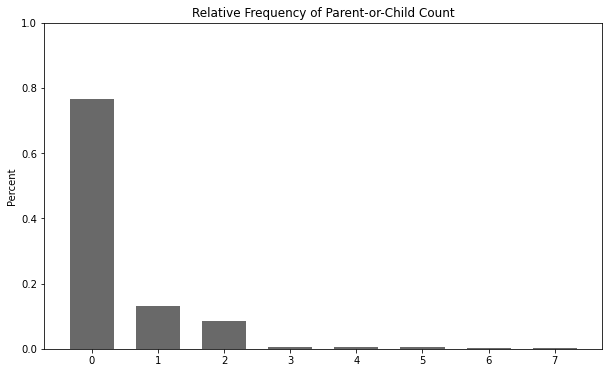

In [33]:
x = range(parch_counts.shape[0])
width = 1/1.5

figure = plt.figure(figsize=(10, 6))

axes = figure.add_subplot(1, 1, 1)
axes.bar(x, parch_counts["Frequency"], width, color="dimgray", align="center")
axes.set_xticks(x)
axes.set_xticklabels([str(i) for i in x])
axes.set_title( "Relative Frequency of Parent-or-Child Count")
axes.set_ylabel( "Percent")
axes.set_ylim((0,1))
axes.xaxis.grid(False)

plt.show()
plt.close()

The distribution is again skewed right and we see a Power Law pattern with 0's outnumbering 1's and 1's outnumber 2's, etc.

### Fare (`fare`)
Fare is how much each passenger paid for their ticket, in British Pounds.
How much did a typical ticket cost in 1912 for a transatlantic crossing?
There's a lot of information about translantic fares in this [paper](http://eh.net/eha/wp-content/uploads/2013/11/Weissetal.pdf).
In 1880, a single steerage (Titanic did not have "steerage") [ticket](https://www.gjenvick.com/Immigration/ImmigrantTickets/1880-05-29-SteamshipTicket-Prepaid-Steerage.html) was \\$32.00 from NY/Boston to UK.
That's \\$848 in current (2020) dollars.
This doesn't help us much as the fares are recorded in British Pounds.
A little [research](https://steemit.com/money/@lixtiklipbalm/exchange-rate-of-british-pound-to-american-usd-in-1912-to-now) suggests that the exchange rate *aboard the Titanic* was 4.95 USD to 1.00 GBP so that \\$32.00 would be 6.46 GBP.
We still have to contend with 32 years of inflation and different prices for 1st, 2nd, and 3rd class but it's a start.



<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
<p>Normally, we'll have better domain knowledge when working on business problems since we'll have access to proprietary information and stakeholders.
Sometimes you'll have to go out and find the domain knowledge yourself.</p>
<p>You are expected to go out and learn a bit about the data...even for Labs and Problem Sets.</p>
</div>

We can use this as a general benchmark.
Our examination above indicates we're missing one value.
Whatever the *mean* fare, there will probably be a Pareto distribution of fares.
Most of the fares will be lower to middle with fewer higher fares.
The fares may also be "bunched" up a key/important values.


In [34]:
pd.DataFrame(titanic["fare"].describe())

,fare
count,1308.000000
mean,33.295479
std,51.758668
min,0.000000
25%,7.895800
50%,14.454200
75%,31.275000
max,512.329200


The mean fare was 33.30 GBP (actually, Pounds Sterling but that's ok).
The minimum fare was 0.0 (kids sail free?) and the maximum fare was 512 GBP.
The distribution looks skewed because the mean is above the 3rd Quartile.
This isn't unusual for prices.

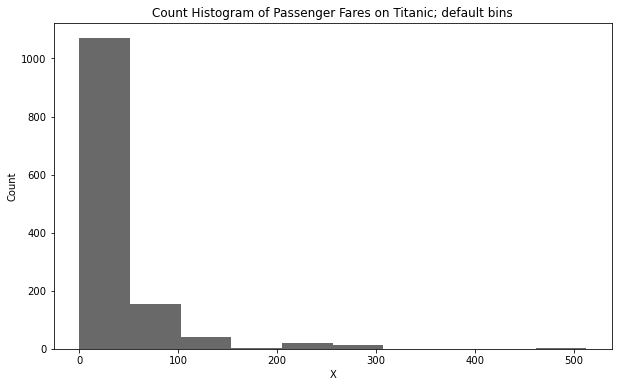

In [35]:
figure = plt.figure(figsize=(10, 6))

axes = figure.add_subplot(1, 1, 1)
axes.hist( titanic[ "fare"], color="DimGray")
axes.set_ylabel( "Count")
axes.set_xlabel( "X")
axes.set_title("Count Histogram of Passenger Fares on Titanic; default bins")


plt.show()
plt.close()

Most fares were well below 100 GBP.
The distribution is extremely skewed, following a very strong Power Law pattern.

### Cabin (`cabin`)
Cabin could have been an interesting variable because we could have localized the passenger's cabin to a specific deck rather than just class of travel.
However, there are only 295 records with values (out of 1309) so the variable isn't useful to us.

### Survived (`survived`)

The variable is categorical (boolean) and particularly important because whether or not a passenger survived is the main qesution of interest for this data set.
The "key" variable is often called the *target* variable.
We already know that not everyone survived but how much, *exactly*, is "not everyone", 50%, 30%, 70%?

In [36]:
survived_counts = summarize_category(titanic["survived"])

In [37]:
survived_counts

,Count,Frequency
0.0,809,0.618029
1.0,500,0.381971


Based on this data, 500 (38%) of the passengers survived.

Interpreting this as a probability, we have:

$p(survived: true) = 38.2\%$

Basically, if you pick a passenger at random on December 13, there is a 38% probability that the passenger survives the sinking the next day.
Unfortunately, there is a 62% probability that they do not:

$p(survived: false) = 61.8\%$

When we get to conditional probability later, we'll use this as our baseline or "null" model.
Basically, any person we "grab" at random, we would assign a 38% probabilty of survival.
We'd like to do better.

## Urns and Titanic

We keep saying "if you pick a passenger at random...".
This comes from a very traditional way of explaining probability, which uses balls of different colors in an urn.
The probability of some event (a ball of certain color) is the probability of a drawing that ball from the urn (usually with replacement...this maintains the "iid" assumption, otherwise, we don't have *identical* probabilities for picking the first red ball and picking the second red ball).
In this case, "a ball of a certain color" might be a survivor, a male survivor, or even a female 3rd class death.
However, it's not immediately clear how Titanic fits this traditional probability narrative because, well, it already sank and we have all the data.
We don't need to predict the next survivor we're going to see.

However, it's still useful to use this kind of artificial language to think about data, even from a one-time process in the past.
You can think of a probability distribution as a predictive model along lines of the what we did in the last example.
"If you pick a passenger at random on December 13, what's the probability that they were female?" "What's the probability that they survive the sinking?" What do you believe is true and to what extent?

There's no doubt, however, that it's much easier to think about these things in the context of current, on-going processes: "What's the probability that someone visiting my website for the 5th time, who left something in their shopping cart, will finally make a purchase?"
Don't just dismiss the example as inapplicable to the real world today.

## Marginal Probabilities


According to E. T. Jaynes, *Probability Theory: The Logic of Science*, there is no such thing as a (pure?) marginal probability: $P(x)$, there are only conditional probabilities: $P(x|*)$.
That is, a probability is always conditioned on something like "the world, the experiment, and the experimental design" and you are just marginalizing those out.
Previously, we talked about the probability of survival as `P(survive) = {yes: .38, no: 0.62}`.
For Jaynes, this is really `P(survive|*)` where `*` is "the world, the experiment, and the experiment design".
We've seen this before.
The probability of a fair coin coming up either heads or tails is 50/50.
We can write this as `P(heads)` where `heads = {yes: 0.5, no: 0.5}`.
But for Jaynes, this is `P(heads|*)` where "*" includes flipping the coin on Earth (and not Mars), the laws of physics, initial conditions, etc.
The `*` is essentialy our ignorance...and we're always ignorant of something.
We leave the `*` implied.

However, this does mean that all the probabilities we've looked at have been conditional probabilities with `*` implied.
Let's start looking at some *explicit* joint and conditional probabilities.

## Joint and Conditional Probability

In a previous section, we looked at single variable EDA and generated marginal (wink, wink) probabilities.
Now we want to start looking at joint and conditional probabilities.
What is the probability that someone is male and a 3rd class passenger?
What is the probability that someone is female and a 1st class passenger?
With eight (8) variables, that's 28 combinations of just *two* variables and, well, way beyond our patience to look at.
We will stick to some interesting ones for now.
When you "do" EDA, pairwise analysis is guided by your question or problem.



### Survival and Sex

Because of the differing interpretations of "women and children first", survival and sex have always been an interesting pair of variables to look at in the Titanic data set.
We can calculate: `P(survive, sex)` from the data:

In [38]:
pd.crosstab(titanic["survived"], titanic["sex"], normalize='all')

sex,female,male
survived,,
0.0,0.097021,0.521008
1.0,0.258976,0.122995


The output above shows all possible events in the space, that is, the combinations of survival (yes or no) and sex (male or female).
Pandas will handle that.


<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>The documentation for the <a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html">crosstab</a> function.
</div>

When you run these kinds of queries on a database, you have to be careful that all the events are present in the data.
It might be possible that some of the individual outcomes are not present and you have to think about what to do because of the missing data.
Usually, you will just have to ignore it and, essentially, normalize over it.

For example, if we'd done this directly in a database (as you often do), we might have taken this approach (with a dataframe standing in for a database):

In [39]:
query = f"""
SELECT survived, sex, count(*) AS cnt, count(*)/{float(passengers)} AS pct 
FROM titanic 
GROUP BY survived, sex 
ORDER BY survived, sex
"""
survived_and_sex_counts = pysqldf(query)

In [40]:
survived_and_sex_counts

,survived,sex,cnt,pct
0,NaN,None,1,0.000763
1,0.0,female,127,0.096947
2,0.0,male,682,0.520611
3,1.0,female,339,0.258779
4,1.0,male,161,0.122901


The output above is interesting because it implies that any such SELECT/GROUP BY query of this sort is, even implicitly, a probability distribution over those joint events (although expressed as absolute counts...it's certainly *proportional* to some joint probability distribution).
This can be a helpful way of looking at your data and thinking about the process that generates (or generated) it.

What does the output say?
It says, for example, the probability of choosing a passenger who survived and was male is 12.3%.
The probability of choosing a passenger who was female and did not survive was 9.7%.

This isn't normally what we want, however.
We generally are looking for a predictive model: we want to predict survival based on sex.
"Based on sex" is the same as "given sex" so by a happy coincidence, `P(survival|sex)` can be a predictive model.
We can think about this coincidence in two ways:

1. conditional probability is a simple predictive model
2. conditional probability is always the implicit predictive model, even if we use a different form of model.

We're side-stepping the definition of a model here but we can think of a "model" as any simplifying representation of data that helps us summarize, explain, or predict.

<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Application</strong>
    <p>
Think of a problem at work where you need to explain or predict. Express it as a conditional probability. How many variables are there? How large would the conditional probability table be (assuming you discretized numeric variables into a reasonable number of buckets)?</p>
</div>

It's a bit more difficult to do *conditional* probability in a SQL query so let's return to our Pandas methods:

In [41]:
pd.crosstab(titanic["sex"], titanic["survived"], normalize='index')

survived,0.0,1.0
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


Using probability notation, we have:

$P(survived=yes|female=yes) = 72.7\%$

$P(survived=no|female=yes) = 27.3\%$



<div style="background: lemonchiffon; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>The <em>preference</em> is to have *rows* for the "given" variable or variables so that you can read across "given sex is female, the probability of not surviving is".
    The rows will thus sum to 1.</p>

<p>However, if one variable has a lot more possible values than the other, you may want to switch up this convention so that the table fits on the screen.</p>
</div>

We can also create a model (conditional probability distribution) for the opposite: `P(sex|survived)`, if someone survived, what is the probability that they're male or female?

In [42]:
pd.crosstab(titanic["survived"], titanic["sex"], normalize='index')

sex,female,male
survived,,
0.0,0.156984,0.843016
1.0,0.678000,0.322000


It says, given the survival status, what is the probability that the passenger was male or female:

$P(sex=male|survived=no) = 84.3\%$

$P(sex=female|survived=no) = 15.7\%$

$P(sex=male|survived=yes) = 32.2\%$

$P(sex=female|survived=yes) = 67.8\%$

Here is a stark reminder that P(A|B) doesn't always equal (and doesn't *usually* equal P(B|A).
This is also the place where you want to start to check the predictive power of your model.
First, we note that the probability of:

In [43]:
summarize_category(titanic["sex"])

,Count,Frequency
female,466,0.355997
male,843,0.644003


 picking a male amongst the passengers was 64.4% but the probability of picking a male amongst the *survivors* was only 32.2%.
Given a male passenger, there was only a 19% chance they survived.

Let's look at the class of the passenger next.

### Survival and Passenger Class

We have a general sense here that first class passengers were more likely to to have survived than third class passengers.
We might base our beliefs on some ideas about economic advantage (maybe people thought first class passengers were more valuable or they thought they were more valuable).
However, it's much more likely that first class passengers survived because of the hour of the accident (11pm local time) and the location of the first class passengers on the ship.

One thing that happens a lot as you do analysis it that begin to accummulate a set of analyses that you know you want to do.
We are probably going to want both `P(survival|pclass)` and `P(pclass|survival)`.
In any case, let's see what the data shows.
Here's a refresher on the absolute counts and marginal probability `P(pclass)`:


In [44]:
summarize_category(titanic["pclass"])

,Count,Frequency
1.0,323,0.246753
2.0,277,0.211612
3.0,709,0.541635


And here's the joint probability `P(survived, pclass)`:

In [45]:
pd.crosstab(titanic["pclass"], titanic["survived"], normalize="all")

survived,0.0,1.0
pclass,,
1.0,0.093965,0.152788
2.0,0.120703,0.090909
3.0,0.403361,0.138273


Looking at the joint probabilities, it's tempting to conclude that passenger class did not make a difference for survival:

$P(survived=1, pclass=1) = 15.3\%$

$P(survived=1, pclass=3) = 13.8\%$

Let's move right to the conditional probabilities to see if this is true (or how it might be true or false)...


In [46]:
pd.crosstab(titanic["pclass"], titanic["survived"], normalize="index")

survived,0.0,1.0
pclass,,
1.0,0.380805,0.619195
2.0,0.570397,0.429603
3.0,0.744711,0.255289


So,

$P(survived=1|pclass=1) = 61.9\%$

$P(survived=1|pclass=2) = 42.6\%$

$P(survived=1|pclass=3) = 25.5\%$

The difference is quite a bit larger than the joint probability would suggest.
First class passengers were more than twice as likely to be rescued (61.9/25.5 = 2.5) and second class passengers were slightly less than twice as likely to be rescued (42.6/25.5 = 1.7).


<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>   
Can you think of a different variable that might explain this pattern based on the analysis we conducted earlier?
(We might call this an "interaction" between that variable and pclass that is causing the results to be other than what we expect).
What additional characteristic might shed light on these disparities?</p>
    <p>This is the perfect kind of thing to note here and look at later, when you move on to pairwise comparisons</p>
</div>

Let's look at it the other way, what is the probability of passenger class, given that the passenger survived?

In [47]:
pd.crosstab(titanic["survived"], titanic["pclass"], normalize="index")

pclass,1.0,2.0,3.0
survived,,,
0.0,0.15204,0.195303,0.652658
1.0,0.40000,0.238000,0.362000


The results here are closer to what our intuitions might be given the joint probabilities we observed.
Why?
Here we see that:

$P(pclass=1|survived=1) = 40.0\%$

$P(pclass=2|survived=1) = 23.8\%$

$P(pclass=3|survived=1) = 36.2\%$

So why are they so much closer here than the other way around?
Remember that conditional probability is defined as:

$P(A|B) = \frac{P(A, B)}{P(B)}$

or

$P(B|A) = \frac{P(A, B)}{P(A)}$

This means that:

$P(A, B) = P(A|B)P(B)$

or

$P(A, B) = P(B|A)P(A)$

In the first case, B is survived.
The fact that so few passengers survived gets filtered through that conditional probability, arriving at the joint we observed.

In the second case, A is passenger class.
There are twice as many third class passengers as first class passengers.
That in turn gets filtered through this conditional probability to arrive at the same joint.

Basically, this is just $P(A|B) \ne P(B|A)$ all over again plus the added bonus that you can't deduce either from $P(A, B)$.



### Age

We previously looked at age and saw that passengers were generally young adults in their 20s and 30s.
There were some children aboard but not very many, relatively speaking.
With each decade, the proportion of passengers dropped.
But what influence (if any), was age likely to have had on survival?

There are a various possible hypothesizes.
First, wealth generally comes with age and we know there's a slight advantage in survival for first class over third class passengers.
Second, we're aware of stories of older passengers giving up their places to younger ones.
A reasonable hypothesis is that there's no difference.

In [48]:
pd.crosstab(titanic["decade"], titanic["survived"], normalize="index")

survived,0.0,1.0
decade,,
0.0,0.390244,0.609756
10.0,0.608392,0.391608
20.0,0.630814,0.369186
30.0,0.577586,0.422414
40.0,0.614815,0.385185
50.0,0.542857,0.457143
60.0,0.687500,0.312500
70.0,0.857143,0.142857
80.0,0.000000,1.000000


The first thing we should note is that we don't have the same amount of data for each age group (decade) and so our conclusions will not all be equally supported.
Our model says that all 80 year olds live.
That seems unlikely.
(BTW, that "unlikely" or "likely" feeling you have *is* a Bayesian prior probability...Bayesian inference *formalizes* that feeling by making you write it down as math).

Let's look at the raw counts:

In [49]:
pd.crosstab(titanic["decade"], titanic["survived"])

survived,0.0,1.0
decade,,
0.0,32,50
10.0,87,56
20.0,217,127
30.0,134,98
40.0,83,52
50.0,38,32
60.0,22,10
70.0,6,1
80.0,0,1


We can think of the count as the amount of *evidence* for each probability (model).
We'll see later how to use statistical inference to determine how much we should believe our model based on the evidence but for now, we're just going to go with our "gut" feeling.
With only 1 observation, obviously we shouldn't believe the model saying "80 year olds have a 100% chance of surviving".
Note that this is not the same thing as saying "All 80 year olds aboard the Titanic survived".
There was one, and they did.
But it's not a good model of why someone survived because there's only one instance.
Nor is it a good predictor for a future sinking.

Similarly, the probability of not surviving, given you're a  70 year old is quite low.
This seems similarly unlikely (notice the implicit prior again, you should write these down before you actually do the data analysis).

It seems even more unlikely given the pattern in the other conditional probabilities.
For 10 year olds to 50 year olds, the overall trend is quite similar...39%, 37%, 42%, 39%...they're within 5 percentage points of each other.
There appears to be a sharp increase for 50 year olds (46%) and sharp drop for 60 year olds (31%).
But again, there may be confounding factors...were more 70 year olds 1st class or 3rd class, male or female?

Let's look at the opposite conditional probability, $P(decade|survived)$.
This conditional probability will answer the opposite question: given someone survived (or didn't), how old were they?
What do you think it'll be?
What factors will influence it?
Write it down.

In [50]:
pd.crosstab(titanic["survived"], titanic["decade"], normalize="index")

decade,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0
survived,,,,,,,,,
0.0,0.051696,0.140549,0.350565,0.216478,0.134087,0.061389,0.035541,0.009693,0.000000
1.0,0.117096,0.131148,0.297424,0.229508,0.121780,0.074941,0.023419,0.002342,0.002342


The results are fairly interesting.
Except for those under 10, the probability that a passenger survived or not, given there age (at least by decade) is pretty uniform.


### Summary

This should give  you the basic idea of:

1. how probabibility and conditional probability figure into data science, and specifically, exploratory data analysis.
2. how conditional probability can be used to explicitly model relationships between features.
3. how conditional probability is still the implicit model even if we don't use it explicitly.

Basically, everything is probability. We have a process about which we have collected data and we're uncertain about the results because the world changes and the data we obtained is only a partial glimpse into the process.

For the second point, if our domain knowledge establishes a relationship, we can see how certain we should be about that relationship. Another way of putting it is how credible or believable that relationship is.


The last point is interesting and important.
Most machine learning techniques from logistic regression to deep learning are function approximation techniques: inputs go in and labels come out.
Except that labels don't come out...what comes out of these models is numbers on the interval (0, 1) that we broadly interpret as probabilities.
Thus most machine learning techniques are approximating the conditional probability distribution:

$P(Y|X_1, X_2, X_3,..., X_n)$

where $Y$ is the target variable.
In the discrete case $Y$ is a categorical variable with various categories.
We usually class this $Y$ "the class" and the values of $Y$, "class labels" or "labels".
There quite a few different names for these things, depending on the field.

We turn to function approximation to represent the conditional probability for a number of reasons:

1. We many not have representatives of all possibilities. As we saw with 80 year olds, we often don't have the data we need. Function approximation can interpolate over missing values.  However, we still need to be wary of applying our models outside of situations represented in the training data.
2. Consider a problem with 10 $X_i$ features, each with 4 possibilities. This would require a conditional probability table that has $4^{10}$ or 1,048,576 entries *and* we would need data to estimate them all (technically, we could fill all the cells with our prior beliefs and then estimate the posterior distribution but we still need 1,048,576 cells!)

Of course, if $Y$ or any of the $X_i$ are continuous--the case we have sought to avoid throughout this case study--function approximation may be the only way to estimate the conditional probability.
We'll be ignoring continuous $Y$ until later in the course.

It's worth nothing that probability cannot establish causality.

### Survived, Class, Gender

A few analyses back, we looked at survival by passenger class and wondered if there might not be a confounding variable.
Specifically, we want to think about $P(survived|pclass, X_j)$ where $X_j$ is that confounder.
Using our current approach (`pandas`'s `crosstab()`) we would need one table $P(survived|class,X_1=x_i)$ for each $x_i$ of $X_j$.
Suppose we wanted a to look at another factor, $X_2$?
This gets a bit cumbersome.

<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>
If we did want to look at the conditional probability of $P(survived|pclass, X_1, X_2)$, what specific conditional probability would each table represent? For example, if $X_1$ has 4 values and $X_2$ has 6 values, how many tables are there?</p>
</div>

As with all such things, there are several ways to approach this (technical) problem.
First, we could just create multiple crosstabulations.
It would be kind of difficult to interpret and compare these, however.
Second, we could use the SQL approach and we'll demonstrate that approach because there are times when you will be doing your analysis directly in the database.
It's good to know how to do things in SQL without having ETL a database into a different server or local laptop for analysis.
This is especially true in the early stages of a project, when you're trying to see if there's any "there" there.
Third, we can write a function to maninpulate a DataFrame and make it do what we want.
We will eventually take this approach.

In the following discussion, we will look at the the probability of $P(survived|pclass, gender)$ and then introduce a specific algorithm for modeling conditional probabilities based on Bayes Rule.

In our previous analysis we noted the disparity in survival rates for different passenger classes:

In [51]:
pd.crosstab(titanic["pclass"], titanic["survived"], normalize="index")

survived,0.0,1.0
pclass,,
1.0,0.380805,0.619195
2.0,0.570397,0.429603
3.0,0.744711,0.255289


However, this "model" doesn't take any other factor into account.
We also know that gender influenced survival rates among Titanic's passengers:

In [52]:
pd.crosstab(titanic["sex"], titanic["survived"], normalize="index")

survived,0.0,1.0
sex,,
female,0.272532,0.727468
male,0.809015,0.190985


So here's an interesting question:
is it possible for both of these conditional probabilities to hold and for there to be *no* relationship between pclass and sex?


<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>
You should be able to answer this question mathematically starting with the joint probability distribution.</p>
</div>

Let's look empirically.
What we're wondering is if the conditional probabilities are the same, whether we look at $P(sex|pclass)$ or $P(pclass|sex)$ and we can actually answer this question by looking at the joint $P(sex, pclass)$.
Let's use the SQL approach:


In [53]:
query = f"""
SELECT pclass, sex, count(*) AS cnt, count(*)/{float(passengers)} AS pct 
FROM titanic 
GROUP BY pclass, sex 
ORDER BY pclass, sex
"""
pclass_and_sex_counts = pysqldf(query)

What do you think we'll see?

In [54]:
pclass_and_sex_counts

,pclass,sex,cnt,pct
0,NaN,None,1,0.000763
1,1.0,female,144,0.109924
2,1.0,male,179,0.136641
3,2.0,female,106,0.080916
4,2.0,male,171,0.130534
5,3.0,female,216,0.164885
6,3.0,male,493,0.376336


The proportion of $P(3, male)$ is huge compared to the others.
We can calculate the conditional probabilities by hand:

$P(male|pclass=3) = 0.377/(0.377+0.165) = 69.6\%$

$P(female|pclass=3) = 0.165/(0.377+0.165) = 30.4\%$

So, *given* that you're in 3rd class, the probability of being male is nearly 70% while the probability of being female is only 30%.

$P(1|sex=male) = 0.137/(0.137+0.131+0.377) = 21.2\%$

$P(2|sex=male) = 0.131/(0.137+0.131+0.377) = 20.3\%$

$P(3|sex=male) = 0.377/(0.137+0.131+0.377) = 58.4\%$

And, *given* that you're male, it is much more probable that you're in 3rd class.

So this presents an interesting question for us...because `pclass` and `sex` are related, were women more likely survive because they were in first class or because they were women?
Put differently, do we even need pclass to explain survivorship?


<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>Think about the question a minute. Why or why not?</p>
</div>

My hypothesis is that you need both.
The reason is that while sex may explain why more women survived than men, some men *did* survive and some women *did not* survive.
The explanation may be passenger class.

Let's start by calculating $P(survived, pclass, sex)$, the full joint probability.

<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
What do you think the joint probability will look like?
What do you think will be the most common subsets?
</p>
</div>

We already know that 3rd class, male passenger non-survivors are probably the largest subset.
What do you think is the next largest group?
What groups are in the top 5?

1st class female passengers survivors are probably also a large group but it's hard to say definitely what the other groups will be...we can calculate the joint probability easy enough in a SQL statement:


In [55]:
query = f"""
SELECT survived, pclass, sex, count(*) AS cnt, count(*)/{float(passengers)} AS pct 
FROM titanic 
GROUP BY survived, pclass, sex
ORDER BY pct DESC
"""
survived_pclass_and_sex_counts = pysqldf(query)

In [56]:
survived_pclass_and_sex_counts

,survived,pclass,sex,cnt,pct
0,0.0,3.0,male,418,0.319084
1,0.0,2.0,male,146,0.111450
2,1.0,1.0,female,139,0.106107
3,0.0,1.0,male,118,0.090076
4,0.0,3.0,female,110,0.083969
5,1.0,3.0,female,106,0.080916
6,1.0,2.0,female,94,0.071756
7,1.0,3.0,male,75,0.057252
8,1.0,1.0,male,61,0.046565
9,1.0,2.0,male,25,0.019084


As we thought, 3rd class male passenger non-surivivors is the largest group, by far.
They are almost three times larger than the next group.
Note, however, that as the percentages decrease, the base counts decrease as well.
We're starting to observe that, as you increase the specificity of your subsets, you have less data to support estimates for those subsets and the probability estimates may be unreliable (they could have gone in the other direction as well, being highly probable, they didn't in this case).

Now we'll switch to the DataFrame approach and a helper function to calculate conditional probabilities of more than two variables.
You can use this instead of `crosstab()`:

In [57]:
def conditional_probability(df, target, givens, cell="index"):
    """
    calculates a simple conditional probability (only one target variable) based off of:
    https://stackoverflow.com/questions/54040923/change-order-of-pandas-multiindex
    
    P(target|givens...)
    
    df: the DataFrame to use for the calculation
    target: the string name of the target variable
    givens: a string or List of strings that represent the "givens"
    cell: a column that is neither target nor givens to "count". Should be a column without NA.
    
    The default assumes you have added a column: df["index"] = df.index to your DataFrame.
    """
    if isinstance(givens, str):
        givens = [givens]
    print(f"P({target}|{', '.join(givens)})")
    columns = [target] + givens
    # handling multiple targets would require a more sophisticated join.
    result = (df.groupby(columns).count() / df.groupby(givens).count())[cell]
    # this makes sure the target is always the column
    result = result.reorder_levels(givens + [target]).sort_index()
    # this flattens the hiearchical index and should fill in missing values.
    result = result.unstack(fill_value=0.0)
    return pd.DataFrame(result)

We can calculate the conditional probability as follows:

In [58]:
conditional_probability(titanic, "survived", ["pclass", "sex"], "name")

P(survived|pclass, sex)


survived            0.0       1.0
pclass sex                       
1.0    female  0.034722  0.965278
       male    0.659218  0.340782
2.0    female  0.113208  0.886792
       male    0.853801  0.146199
3.0    female  0.509259  0.490741
       male    0.847870  0.152130

The "name" field at the end of the function call is a bit weird. 
It's the column that needs to be counted and turned into relative frequencies.
It must be a column with no nulls and it can't be either the "target" or the "givens".
The documentation explains how to add such a field if needed.

First, let us tackle these results.
As we had before, each row is the "givens" and each column is a value of the target variable (often called "class labels").
The first row and column then says, given that you were a first class, female passenger, you had a 3.5% probability of not surviving; the second column says a 96.5% probability of not surviving.
The next row gives the data for men in first class and the odds of survival were signficantly worse (nearly one third) with 34% versus 66%.

For second class passengers, women had a higher probability of survival (89% versus 11%).
It was not *hugely* lower than the probabilities for first class women passengers.
Second class *male* passengers, on the other hand, faired significantly worse than first class male passengers, 15% compared to 34% survival.

For third class passengers, women had about a 50/50 chance of survival.
Men, on the other hand, had only a 15% chance of survival, about the same as second class passengers.

In all cases, women had a higher survival rate than men.
However, even among woman, the survival rates were not the same amongst the classes.
The rates are very similar for first and second class but not third class.

The rule for independence is that:

$P(A|B, C) = P(A|B)$

We can look at two:

$P(survived=1|pclass=1, sex=female) = 96.5\%$ $\neq$ $P(survived=1|pclass=1) = 61.9\%$ $\neq$ $P(survived=1|sex=female) = 72.7\%$

so we can see that independence does not hold here.
Therefore, both sex and passenger class mattered for predicting survival.

## Other Relationships

Although we have looked mostly at the target variable, `survived`, during our exploration of conditional probability, we are free to look at other relationships as well.
For example, what relationship was there between `pclass` (passenger class) and sex, sibling/spouse relationship, and parents/children?

In [59]:
conditional_probability(titanic, "pclass", ["sex", "sibsp", "parch"], "name")

P(pclass|sex, sibsp, parch)


pclass                   1.0       2.0       3.0
sex    sibsp parch                              
female 0.0   0.0    0.268041  0.216495  0.515464
             1.0    0.515152  0.242424  0.242424
             2.0    0.206897  0.310345  0.482759
             3.0    0.000000  0.500000  0.500000
             4.0    0.000000  0.000000  1.000000
             5.0    0.000000  0.000000  1.000000
       1.0   0.0    0.466667  0.200000  0.333333
             1.0    0.279070  0.279070  0.441860
             2.0    0.277778  0.500000  0.222222
             3.0    0.333333  0.333333  0.333333
             4.0    0.500000  0.000000  0.500000
             5.0    0.000000  0.000000  1.000000
             6.0    0.000000  0.000000  1.000000
             9.0    0.000000  0.000000  1.000000
       2.0   0.0    0.428571  0.000000  0.571429
             1.0    0.000000  0.571429  0.428571
             2.0    0.500000  0.000000  0.500000
             3.0    0.000000  1.000000  0.000000
       3.0   0.0    0.000000  0.500000  0.500000
             1.0    0.000000  0.000000  1.000000
             2.0    0.600000  0.000000  0.400000
       4.0   2.0    0.000000  0.000000  1.000000
       5.0   2.0    0.000000  0.000000  1.000000
       8.0   2.0    0.000000  0.000000  1.000000
male   0.0   0.0    0.181208  0.194631  0.624161
             1.0    0.526316  0.105263  0.368421
             2.0    0.357143  0.285714  0.357143
       1.0   0.0    0.376344  0.258065  0.365591
             1.0    0.234043  0.319149  0.446809
             2.0    0.363636  0.272727  0.363636
             3.0    0.500000  0.000000  0.500000
             4.0    0.500000  0.000000  0.500000
             5.0    0.000000  0.000000  1.000000
             6.0    0.000000  0.000000  1.000000
             9.0    0.000000  0.000000  1.000000
       2.0   0.0    0.105263  0.263158  0.631579
             1.0    0.000000  1.000000  0.000000
             2.0    0.500000  0.000000  0.500000
       3.0   0.0    0.000000  0.000000  1.000000
             1.0    0.000000  0.000000  1.000000
             2.0    0.333333  0.000000  0.666667
       4.0   1.0    0.000000  0.000000  1.000000
             2.0    0.000000  0.000000  1.000000
       5.0   2.0    0.000000  0.000000  1.000000
       8.0   2.0    0.000000  0.000000  1.000000

So that's kind of hard to look at.
There are several problems going on here, all at once.
First, some of the events (like ["male", 8, 0] are missing and other's like ["female", 1, 2] have small counts.
Second, while we avoided multiple tables, we still have one huge table.
It would be awful to put this in a report and say "you explore it".
At least one thing we can do is color code the values so that we can make better use of our visual perception.

In [60]:
import seaborn as sns

In [61]:
cpt = conditional_probability(titanic, "pclass", ["sex", "sibsp", "parch"], "name")
cm = sns.light_palette("blue", as_cmap=True)
cpt.style.background_gradient(cmap=cm)

P(pclass|sex, sibsp, parch)


That's a bit better but we still have a problem with the extreme values creating visual clutter.
It's probably best to generate the whole table and then zero in on elements we think are interesting (or may be interesting) and then extract them:

In [62]:
cpt.loc[[("female", 0, 0), ("female", 0, 1)]]

pclass                   1.0       2.0       3.0
sex    sibsp parch                              
female 0.0   0.0    0.268041  0.216495  0.515464
             1.0    0.515152  0.242424  0.242424

Here we can zero in on the differing conditional probabilities associated with a female passenger without siblings or spouse present who does or does not have parents/children present.
Here we see that having a parent/child present makes this particular female passenger more likely to be in 1st class as compared to a similar female passenger without a parent/child present.
Of course, this could be comparing a single female accompanying their wealthy parents and a widowed woman with her only child, heading to the New (to her) World and hopefully a better life.

## Bayes Rule and the Naive Bayes Classifier

Seeing the bit of a mess we get when we grow our conditional probability models too big, let's return to the idea of approximating the conditional probability distribution.
We mentioned previously that all predictive models are at least implicitly conditional probability models (and many are explicitly conditional probability models).
We also noted that you could, in theory, use a conditional probability distribution as a predictive model.
The main obstacle here is that the conditional probability distribution grows exponentially in the number of variables.
The usual alternative is to treat the conditional probability distribution as a function to be estimated and reduce it to a calculation instead of a lookup.
This is essentially what numerical approaches such as logistic regression all the way up to deep learning do.

An alternative is to make simplifying assumptions about the nature of the interactions among variables.
Consider the following version of Bayes Rule:

$P(A|B, C, D, E, F) \propto P(B, C, D, E, F|A)P(A)$

where we use $\propto$ in order to ignore the normalizer.

If each variable has 4 potential values, then the table representing these conditional probability distributions is $4^5$ or 1,024 values.
Remember the Chain Rule of Probability:

$P(A, B, C, D, E) = P(A|B, C, D, E)P(B|C, D, E)P(C|D, E)P(D|E)P(E)$

We can apply this to a conditional probability as well:

$P(B, C, D, E, F|A) = P(B|C, D, E, F, A)P(C|D, E, F, A)P(D|E, F, A)P(E|F, A)P(F|A)$

And then remember the definition of conditional independence from above:

$P(A|B, C) = P(A|C)$

if A and C are conditionally independent of B.

If we *assume* that all features are conditionally independent of each other, then our chain rule above reduces to:

$P(B, C, D, E, F|A) = P(B|A)P(C|A)P(D|A)P(E|A)P(F|A)$

which we can substitute back into our Bayes Rule:

$P(A|B, C, D, E, F) \propto P(B|A)P(C|A)P(D|A)P(E|A)P(F|A)P(A)$

Each conditional probability distribution is now 4x4 or 16 values. We require 5 of them plus the 4 element prior distribution. Instead of 1,024 values we now estimate our posterior distribution using 5 times 16 element tables or 80 values time 4 = 320.

This is quite a bit better than 1,024 and, of course, the savings are larger, the larger the conditional probability table that we're estimating.
That is, the more variables we have and the more values those variables have.

With this simplification in mind, how do we use it as a classifier?

### Naive Bayes Classifier

Returning to the Titanic example, we have the following:

$P(survived|pclass, sex, decade, parch, sibsp) \propto P(pclass|survived)P(sex|survived)P(decade|survived)P(parch|survived)P(sibsp|survived)P(survived)$

Let us suppose that we want to predict the fate of a 2nd class women in her 30s with no family on board Titanic:

$P(survived|2, female, 30, 0, 0) \propto P(2|survived)P(female|survived)P(30|survived)P(0|survived)P(0|survived)P(survived)$

We can make the prediction by calculating the above equation for each possible value of $survived$ (0 and 1):

$P(survived=0|2, female, 30, 0, 0) \propto P(2|0)P(female|0)P(30|0)P(0|0)P(0|0)P(0)$


$P(survived=1|2, female, 30, 0, 0) \propto P(2|1)P(female|1)P(30|1)P(0|1)P(0|1)P(1)$

and pick the outcome that has the higher (estimated) posterior probaliity.
This is the Naive Bayes Classifier, "naive" because we assume all features are independent of each other *given* the target variable.

So, in general, the Naive Bayes Classifier involves:

1. calculating prior probabilities for the target variable.
2. calculating conditional probabilities, $P(X_i|T)$ where $X_i$ is some feature and $T$ is the target variable.

and then when you want to classify something, you calculate:

$P(T=t_j|X_1, X_2,...) \propto \prod_i P(X_i|T) P(T=t_j)$

for each value of T, $t_j$.

We noted that in a very large conditional probability table, we're likely to have empty subsets.
This can happen in Naive Bayes as well.
The general approach is to introduce *smoothing* via pseudocounts...we pretend we saw one count for every possible subset.
This keeps the $\prod$ from imploding on missing values.
You can change the number of pseudocounts if you like...the distribution of the pseudocounts represents a prior on the conditional probabilities!
Bayes is priors all the way down.

Is this good for estimating posterior probabilities? No.
Is it good for classification? Yes, many times because all it has to do is get the *ordering* of probabilities correct.

Let's estimate a Naive Bayes Model just for pclass and sex so we can compare the results with the exactly probabilities we already estimated.
After that, you can build a full model to determine our young woman's *likely* fate.

### Scikit Learn Naive Bayes

Scikit-Learn has a number of implementations for [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html).
We'll be using CategoricalNB because our target variable and features are categorical variables.

In [63]:
from sklearn.naive_bayes import CategoricalNB

As we've already noted, one of the problems for using Conditional Probability distributions is that some of the "cells" (subsets) may be empty and have no values.
This is still possible for the Naive Bayes Classifier.
The constructor for CategoricalNB takes a parameter, `alpha`, that determines the number of "pseudocounts" each subset gets.
This is a form of smoothing or regularization as well that can be used to prevent overfitting.
In Bayesian terms, this is a prior (in Bayesland, it's priors all the way down).

In [64]:
clf = CategoricalNB()

Unfortunately, the CategoricalNB does not work arbitrary strings.
Instead, we need to encode our data using the OrdinalEncoder.

In [65]:
from sklearn.preprocessing import OrdinalEncoder

In [66]:
encoder = OrdinalEncoder()

We have to get rid of all the rows that don't have age values or the Encoder will fail.

In [67]:
with_age = titanic[titanic["age"].notnull()]

We now run the Encoder:

In [68]:
encoder.fit(with_age[["pclass", "sex"]])

OrdinalEncoder()

And here we can see the encoded categories:

In [69]:
encoder.categories_

[array([1., 2., 3.]), array(['female', 'male'], dtype=object)]

We can now fit our classifier using data for passenger class and sex.
We use the encoder to transform it first.

In [70]:
clf.fit(encoder.transform(with_age[["pclass", "sex"]]), with_age["survived"])

CategoricalNB()

We can now make a prediction for a first class female represented as a Tuple (1, 'female') which we first transform.
The predict function expects a "2d Array-like"...basically, a List of Lists or Tuples:

In [71]:
clf.predict(encoder.transform([(1, 'female')]))

array([1.])

Our classifier predicts that she'll survive.
What's the raw probability?

In [72]:
clf.predict_proba(encoder.transform([(1, 'female')]))

array([[0.11580343, 0.88419657]])

We get two probabilities...the probability of 0 (not surviving) and 1 (surviving).
If we refer to our table above, the value isn't *hugely* off.
The empirical estimate is 3% and 97%.
The important point is that the *ordering* is still the same.

In [73]:
survived_pclass_and_sex = conditional_probability(titanic, "survived", ["pclass", "sex"], "name")
survived_pclass_and_sex

P(survived|pclass, sex)


survived            0.0       1.0
pclass sex                       
1.0    female  0.034722  0.965278
       male    0.659218  0.340782
2.0    female  0.113208  0.886792
       male    0.853801  0.146199
3.0    female  0.509259  0.490741
       male    0.847870  0.152130

What about for all the other possiblities?

In [74]:
for tup in [(1, 'male'), (1, 'female'), (2, 'male'), (2, 'female'), (3, 'male'), (3, 'female')]:
    result = clf.predict_proba(encoder.transform([tup]))
    # grab the appropriate two rows
    entry = survived_pclass_and_sex.loc[[tup]]
    not_survived, survived = entry.values[0]
    print(tup, result[0], not_survived, survived)

(1, 'male') [0.60384529 0.39615471] 0.659217877094972 0.3407821229050279
(1, 'female') [0.11580343 0.88419657] 0.034722222222222224 0.9652777777777778
(2, 'male') [0.77170636 0.22829364] 0.8538011695906432 0.14619883040935672
(2, 'female') [0.22507597 0.77492403] 0.11320754716981132 0.8867924528301887
(3, 'male') [0.88231413 0.11768587] 0.847870182555781 0.15212981744421908
(3, 'female') [0.39179595 0.60820405] 0.5092592592592593 0.49074074074074076


<div style="background: tomato; margin:20px; padding: 20px;">
    <strong>Note</strong>
    <p>
        <strong>This is output is bad.</strong>
Don't ever do this...don't just print out raw data structures.
People have to go through your code to figure out what each of the things are.
Instead, take the time to make nice tables.</p>
</div>

In [75]:
#!pip install -U tabulate

In [76]:
from tabulate import tabulate

In [77]:
table = []
for tup in [(1, 'male'), (1, 'female'), (2, 'male'), (2, 'female'), (3, 'male'), (3, 'female')]:
    result = clf.predict_proba(encoder.transform([tup]))
    # grab the appropriate two rows
    entry = survived_pclass_and_sex.loc[[tup]]
    not_survived, survived = entry.values[0]
    row = list(tup) + list(result[0]) + [not_survived, survived]
    table.append(row)

In [78]:
print(tabulate(table, headers=['pclass', 'sex', 'NBC not survived', 'NBC survived', 'Empirical not survived', 'Empirical survived'], floatfmt=".2f"))

  pclass  sex       NBC not survived    NBC survived    Empirical not survived    Empirical survived
--------  ------  ------------------  --------------  ------------------------  --------------------
       1  male                  0.60            0.40                      0.66                  0.34
       1  female                0.12            0.88                      0.03                  0.97
       2  male                  0.77            0.23                      0.85                  0.15
       2  female                0.23            0.77                      0.11                  0.89
       3  male                  0.88            0.12                      0.85                  0.15
       3  female                0.39            0.61                      0.51                  0.49


"NBC" represents posterior probabilities estimated by the Naive Bayes Classifier and "Empirical" is what we estimated above, directly from the data.
We're not *primarily* interested in whether or not the estimates of the conditional probability by the NBC are correct.
We're interested in seeing if the predicted outcomes (ordering of probabilities) are correct.

For first class males, the probabilities aren't far off.
For first class females, they are also very similar.

For second class males, the probabilities are again, close enough in the sense that both models would predict survival or non-survival for the same person (the models agree).
For second class females, the models also agree.

For third class males, the models agree.
For third class females, however, the models do not agree.
The empirical distribution predicts that third class females do not survive while the Naive Bayes Classifier predicts that third class females do survive.
The empirical probability, however, is very nearly a toss-up so this is not unexpected.
Our results could be because of the smoothing or the Naive Bayes Assumption.


<div style="background: palegreen; margin:20px; padding: 20px;">
    <strong>Review</strong>
    <p>Build a full Naive Bayes Classifier using pclass, sex, decade, parch, and sibsp. Make 5 predictions.</p>
    <p>(This is a Lab question)</p>
</div>

## Summary

We covered a lot in this section.

1. We discussed basic concepts in probability including the "urn" model.
1. We talked about the importance of "i.i.d" or independently and identically distributed data.
1. We talked about "tidy" data.
1. We stressed the importance of domain knowledge.
1. We looked at how we might interpret empirical relative frequencies as probabilities.
1. Transform numerical variables into categorical variables so we could use discrete probability distributions.
1. We noted that every probability $P(A)$ is really a marginal probability over a joint probability $P(A, *)$ or a conditional probability $P(A|*)$ where "*" is "absolutely everything else".
1. We applied joint probabilities and conditional probabilities to empirical data, $P(A, B)$ and $P(A|B)$.
1. We demonstrated how we might interpret conditional probabilities as a predictive model.
1. We discussed how conditional probabilities implicitly underlie most predictive models and explicitly underlie many numerical models such as logistic regression, Support Vector Machines (SVM), and artificial neural networks through function approximation of the conditional probability distribution. $P(A|B) = f(A, B)$.
1. We derived the Naive Bayes Classifier from Bayes Rule and applied it to a subset of the Titanic data.

We'll be covering many of these concepts again throughout the semester, either implicitly or explicitly.

**For a similar data set, you should be able to:**

1. Transform numerical variables into categories or "buckets" ("discretize").
2. Calculate relative frequencies and give an interpretation of them as probabilities.
3. Calculate joint and conditional probability distributions from data and interpret them correctly.
4. Fit a Naive Bayes Classifier model to data and make predictions with it.
